# Clustering K-Means. No supervisado.



Proyecto Personal. Hecho con dataset. Consulta personalizada de DataMéxico.
Su objetivo es clasificar en clusters estados por crimenes.

## Importando librerías



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importando el dataset

In [2]:
df = pd.read_csv('Crimenes.csv')
#Visualizar como es el dataframe
df.head()


,State ID,State,Year,Month ID,Month,Crime Type ID,Crime Type,Value
0,1,Aguascalientes,2015,201501,2015-01,101,Abuso de Confianza,41
1,1,Aguascalientes,2015,201501,2015-01,102,Daño a la Propiedad,201
2,1,Aguascalientes,2015,201501,2015-01,103,Despojo,19
3,1,Aguascalientes,2015,201501,2015-01,104,Extorsión,2
4,1,Aguascalientes,2015,201501,2015-01,105,Fraude,119


## Revisando características del dataset

In [14]:
# Revisando características del dataset

df.info()                          # info del dataset
df.isnull().sum()                  # nulos por columna
df.Year.unique()                   # años disponibles
df.shape                           # tamaño del df
df['Crime Type'].unique()          # tipos de delito distintos
df['Value'].describe()             # estadísticas de la columna Value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166400 entries, 0 to 166399
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   State ID       166400 non-null  int64 
 1   State          166400 non-null  object
 2   Year           166400 non-null  int64 
 3   Month ID       166400 non-null  int64 
 4   Month          166400 non-null  object
 5   Crime Type ID  166400 non-null  int64 
 6   Crime Type     166400 non-null  object
 7   Value          166400 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 10.2+ MB


,Value
count,166400.000000
mean,128.383672
std,538.340220
min,0.000000
25%,0.000000
50%,10.000000
75%,66.000000
max,15960.000000


## Transformando el dataset: de formato largo a formato ancho (pivot)

In [15]:
#Agrupa registros por estado y crimen y se suman en value o numero de ese crimen en ese estado


df_wide = df.pivot_table(
    index='State',
    columns='Crime Type',
    values='Value',
    aggfunc='sum'
)
df_wide.head()

Crime Type,Aborto,Abuso Sexual,Abuso de Confianza,Acoso Sexual,Allanamiento de Morada,Amenazas,Contra el Medio Ambiente,Corrupción de Menores,Daño a la Propiedad,Delitos Cometidos por Servidores Públicos,...,Otros Delitos que Atentan contra la Vida y la Integridad Corporal,Rapto,Robo,Secuestro,Trata de Personas,Tráfico de Menores,Violación Equiparada,Violación Simple,Violencia Familiar,Violencia de Género en Todas sus Modalidades Distinta a la Violencia Familiar
State,,,,,,,,,,,,,,,,,,,,,
Aguascalientes,91,19,7450,0,5122,31433,505,701,41770,3219,...,476,0,126487,59,25,7,1016,2169,21876,97
Baja California,539,15560,6674,547,27920,48467,239,4910,89483,10272,...,18166,1,398866,138,379,22,3467,7019,125151,0
Baja California Sur,99,3393,3293,993,2067,16307,33,536,18716,2961,...,1688,1,82248,25,28,0,325,2098,27168,49
Campeche,14,1374,1058,221,1637,8279,60,159,9207,373,...,973,0,22951,38,19,0,1712,783,6348,0
Chiapas,110,2144,1664,699,1235,9859,537,528,14097,2219,...,1209,32,56818,175,285,18,384,5093,30592,1


In [17]:
df_wide.isnull().sum()

,0
Crime Type,
Aborto,0
Abuso Sexual,0
Abuso de Confianza,0
Acoso Sexual,0
Allanamiento de Morada,0
Amenazas,0
Contra el Medio Ambiente,0
Corrupción de Menores,0
Daño a la Propiedad,0


## Feature Scaling

Se estandarizara los datos.

In [20]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df_scaled = sc.fit_transform(df_wide)

df_scaled.shape

(32, 40)

In [21]:
print(df_scaled)

[[-0.39087764 -0.89087343 -0.16876481 ... -0.68284316 -0.81911554
  -0.29079296]
 [ 0.91471926  0.77938243 -0.24927754 ...  0.73633673  0.80115082
  -0.31321109]
 [-0.36756341 -0.52825563 -0.60006816 ... -0.70361878 -0.73609013
  -0.30188647]
 ...
 [ 0.14826393 -0.15091387  0.20889797 ... -0.18452082  0.36148639
   2.92262703]
 [-0.57739149 -0.65421534 -0.38934478 ... -1.01349745 -0.96138206
  -0.30928214]
 [-0.54533442 -0.64948648 -0.57527107 ... -0.83353958 -0.71127036
  -0.31321109]]


## Método del codo (para saber cuantos clusters habrá)

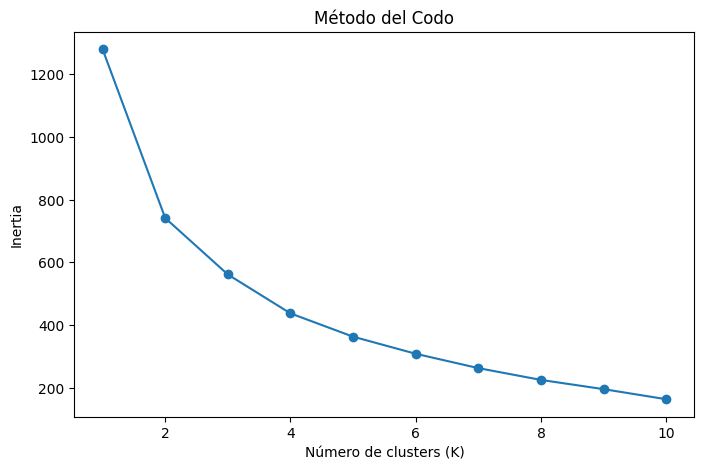

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inertia')
plt.title('Método del Codo')
plt.show()

## Método de Silhoutte Score, para validar el método del codo


In [23]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"K={k}, Silhouette Score: {score:.3f}")

K=3, Silhouette Score: 0.397
K=4, Silhouette Score: 0.392
K=5, Silhouette Score: 0.378


## Aplicando kmeans con 3 clusters
Se confirmó con el método de Silhoutte Score que el mejor número de clusters en este caso era de 3.


In [24]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_scaled)

df_wide['Cluster'] = clusters
df_wide[['Cluster']].sort_values('Cluster')

Crime Type,Cluster
State,
Ciudad de México,0
Estado de México,0
Campeche,1
Aguascalientes,1
Coahuila de Zaragoza,1
Chiapas,1
Colima,1
Baja California Sur,1
Michoacán de Ocampo,1


## Interpretación de centroides

In [25]:
#Copiamos la tabla antes de la estandarizacion
df_wide_con_cluster = df_wide.copy()
#Agrega la columna Cluster con las etiquetas de los clusters.
df_wide_con_cluster['Cluster'] = kmeans_final.labels_

cluster_profile = df_wide_con_cluster.groupby('Cluster').mean()
cluster_profile

Crime Type,Aborto,Abuso Sexual,Abuso de Confianza,Acoso Sexual,Allanamiento de Morada,Amenazas,Contra el Medio Ambiente,Corrupción de Menores,Daño a la Propiedad,Delitos Cometidos por Servidores Públicos,...,Otros Delitos que Atentan contra la Vida y la Integridad Corporal,Rapto,Robo,Secuestro,Trata de Personas,Tráfico de Menores,Violación Equiparada,Violación Simple,Violencia Familiar,Violencia de Género en Todas sus Modalidades Distinta a la Violencia Familiar
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1271.000000,34985.500000,41295.000,14836.000000,13100.500,80165.000000,6718.500000,1858.500,131163.500000,40977.000000,...,8523.000000,31.000000,1.235564e+06,1156.500000,1033.500000,16.500000,8642.500000,13246.500000,238200.500000,10390.500000
1,91.333333,4015.041667,5636.625,1077.583333,2798.625,25775.916667,243.875000,366.125,28218.791667,2500.791667,...,2297.666667,14.875000,1.112884e+05,203.041667,101.500000,19.708333,865.458333,3132.875000,44636.583333,350.458333
2,411.666667,16588.333333,12097.000,2351.666667,8731.000,67090.500000,507.166667,2234.500,85056.500000,8930.333333,...,5154.666667,182.666667,3.180443e+05,352.166667,209.666667,22.000000,1934.666667,7066.833333,137179.000000,2362.500000


## Gráfica

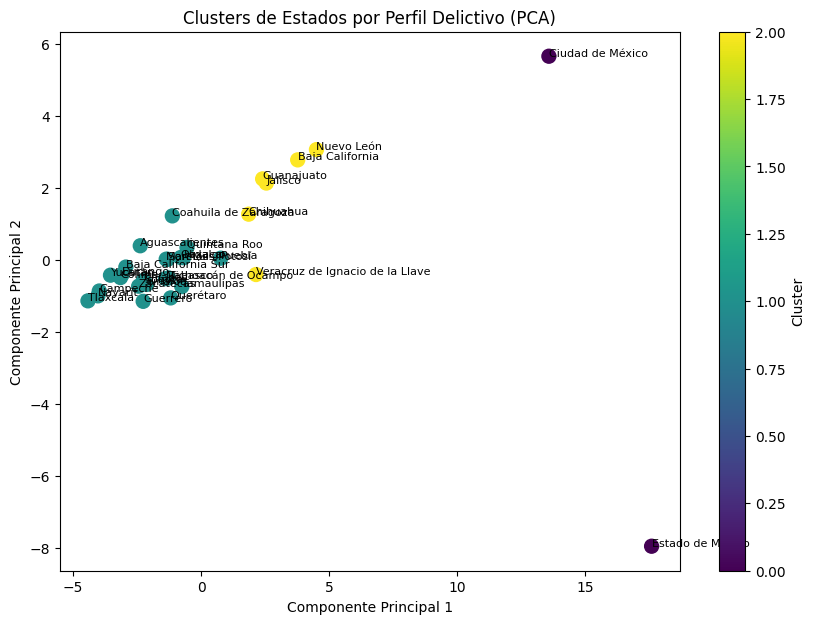

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10,7))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], c=kmeans_final.labels_, cmap='viridis', s=100)
for i, state in enumerate(df_wide.index):
    plt.annotate(state, (pca_result[i,0], pca_result[i,1]), fontsize=8)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters de Estados por Perfil Delictivo (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.show()


## Conclusión — Análisis 1 (Clustering por volumen total)

El modelo K-Means (K=3, silhouette score = 0.40) segmentó a los 32 estados
en tres grupos según el volumen total de incidencia delictiva (2015-2025):

- **Cluster 0 — Alta intensidad**: Ciudad de México, Estado de México.
  Presentan los volúmenes más altos en prácticamente todos los tipos de delito
  (ej. ~1.24M casos promedio de Robo, vs. ~111K en el Cluster 1).
  
- **Cluster 2 — Intensidad media-alta**: Baja California, Chihuahua, Jalisco,
  Guanajuato, Nuevo León, Veracruz. Entidades con alta actividad económica/
  poblacional, con volúmenes intermedios en la mayoría de los delitos.
  
- **Cluster 1 — Intensidad baja**: las 24 entidades restantes, con volúmenes
  consistentemente menores en todos los tipos de delito.

**Hallazgo clave**: la separación entre clusters está dominada por el
**volumen/intensidad total** de criminalidad, que correlaciona fuertemente
con el tamaño poblacional y económico del estado — no por diferencias
cualitativas en el *tipo* de crimen predominante.